# Nội dung bài LAB
1. Mối quan hệ giữa biến đổi Z và bộ lọc mạng feed-forward, feed-backward

2. Thực tập quan sát điểm cực và điểm zeros

3. Bộ lọc Butterworth

4. Bộ lọc Notch và Peak

5. Tự thực hành các bộ lọc Chebyshev I, II, Elippse

6. Ứng dụng bộ lọc biquad IIR

# Learning outcomes của buổi thực hành:
    - Hiểu được vai trò của biến đổi Z
    - Hiểu được vai trò của điểm zero và điểm poles (cực)
    - Hiểu được cách sử dụng thư viện control, đặc biệt là giản đồ bold và giản đồ zeros-poles
    - Hiểu được cách sử dụng các hàm để tạo ra các hàm truyền Z tương ứng với bộ lọc butterworth, Chebysev I, II, Ellipse
    - Hiểu được bộ lọc Notch, Peak


In [1]:


from scipy import signal
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from ipywidgets import interact, Layout
import LabUtils as mylab
import sympy as sym
import control as ctrl
import tensorflow as tf


# 1. Mối quan hệ giữa biến đổi Z và bộ lọc mạng feed-forward, feed-backward


## a. Viết phương trình hệ thống theo miền thời gian

![](https://i0.wp.com/www.gaussianwaves.com/gaussianwaves/wp-content/uploads/2017/02/Direct-form-structures.png?resize=1024%2C542&ssl=1)




In [2]:
def fir_time_expression(b):
    n = sym.symbols('n', integer=True)
    M = len(b)
    x = sym.Function('x')  # Định nghĩa hàm x
    y = sym.Function('y')(n)  # Định nghĩa hàm y
    # Tạo biểu thức y[n] = sum(b_i * x(n - i)) theo đúng thứ tự
    yn = sum(b[i] * x(n - i) for i in range(M))
    # Tạo phương trình với sym.Eq
    fir_expr = sym.Eq(y, yn)
    return fir_expr

b = [0.5, 0.5]
fir_expr = fir_time_expression(b)

sym.pprint(sym.pretty(fir_expr))

y(n) = 0.5⋅x(n) + 0.5⋅x(n - 1)


In [4]:
def iir_time_expression(b, a):
    n = sym.symbols('n', integer=True)
    x = sym.Function('x')  # Định nghĩa hàm x
    y = sym.Function('y')  # Định nghĩa hàm y

    # Tính tổng cho phần tử số
    M = len(b) - 1
    numerator = sum(b[i] * x(n - i) for i in range(M + 1))

    # Tính tổng cho phần mẫu số, bắt đầu từ j = 1 để bỏ qua a[0] = 1
    N = len(a) - 1
    denominator = sum(a[j] * y(n - j) for j in range(1, N + 1))

    # Phương trình tổng quát y[n] = tổng tử số - tổng mẫu số
    yn_expr = numerator - denominator
    iir_expr = sym.Eq(y(n), yn_expr)

    return iir_expr

# Danh sách hệ số bộ lọc IIR
b = [2, -2.05]  # Hệ số tử số
a = [1, -2.05, 1]     # Hệ số mẫu số, a[0] = 1 không được tính vào tổng

# Tính toán phương trình bộ lọc IIR
iir_expr = iir_time_expression(b, a)

# In ra phương trình theo dạng đẹp hơn
sym.pprint(iir_expr, use_unicode=True)


y(n) = 2⋅x(n) - 2.05⋅x(n - 1) - y(n - 2) + 2.05⋅y(n - 1)


## b. Viết phương trình thể hiện hàm truyền ở miền Z

In [5]:

def transfer_function(b, a):
    # Định nghĩa biến và hệ số
    z = sym.symbols('z')
    # Tạo đa thức cho tử số và mẫu số
    B = sum(b[i] * sym.Pow(z,-i) for i in range(len(b)))
    A = sum(a[i] * sym.Pow(z,-i) for i in range(len(a)))

    # Biểu thức hàm truyền
    H_z = B / A
    return H_z

b = [2, -2.05]  # Hệ số tử số
a = [1, -2.05, 1]     # Hệ số mẫu số, a[0] = 1 không được tính vào tổng
H_z = transfer_function(b,a)
sym.pprint( H_z, use_unicode=True)


       2.05  
   2 - ────  
        z    
─────────────
    2.05   1 
1 - ──── + ──
     z      2
           z 


* Câu hỏi:
    - Tại sao khi viết phương trình đáp ứng thời gian của bộ lọc IIR, các hệ số trước phần tử $y(n-1), y(n-2), ....$ phải đổi dấu?
    - Tại sao lúc viết hàm truyền biến đổi Z thì các hệ số trên lại không đổi dấu?
    - Khi nhìn vào hàm truyền biến đổi z, đại lượng $z^{-n}$ có ý nghĩa gì?
    - Các hệ số của thành phần $y(n-1), y(n-2), ....$ được bố trí dưới mẫu hay tử của hàm truyền $H(z)$
    - Về căn bản $z$ là một giá trị thực ($\in \mathbb{R}$) hay phức ($\in \mathbb{C}$)?
    - Khi nhìn vào biểu thức hàm truyền $H(z)$, làm sao nhận biết là hệ thống lọc là FIR, hay IIR?
    

# 2. Thực tập phân tích độ ổn định dựa vào phân tích Z

* Ôn tập:
    - Hàm $H(z) = 0$ khi nào?
    - Hàm $H(z) = \infty$ khi nào?
    - Hàm $H(z)$ bất ổn khi nào?


## a. Xem đáp ứng của hàm truyền ở miền tần số

* Ví dụ sau cho phép hiển thị:
    - hàm truyền H(z) bất kỳ ở miền tần số.
    - xác định vị trí tần số cắt
    - xác định


/opt/anaconda3/lib/python3.12/site-packages/control/freqplot.py:435: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


Tần số tại điểm -3 dB: 0.1483 Hz
Độ dốc ngay sau điểm -3 dB: -9.63 dB/decade


<Figure size 640x480 with 0 Axes>

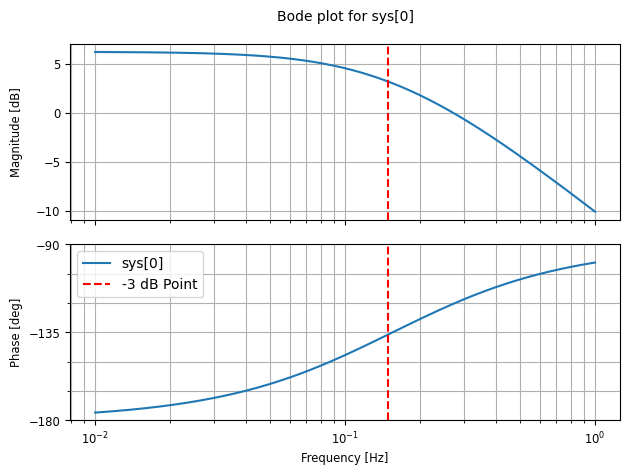

In [2]:
def find_3dB_freq(mag_db,freq):
    init_val_db = mag_db[0]
    target_db = init_val_db - 3  # Mục tiêu là -3 dB từ giá trị ban đầu

    #  Tìm tần số tại đó biên độ giảm 3 dB
    index_3db = np.where(mag_db <= target_db)[0][0]
    freq_3db = freq[index_3db]
    return index_3db, freq_3db

# Định nghĩa hệ số của hàm truyền (ví dụ)
# H(s) = (s + 2) / (s^2 + 3s + 2)
numerator = [2, -2.05]      # Hệ số tử số (s + 2)
denominator = [1, -2.05, 1]  # Hệ số mẫu số (s^2 + 3s + 2)

# Tạo hàm truyền
system = ctrl.tf(numerator, denominator)

plt.figure()
# Vẽ biểu đồ Bode
mag, phase, omega = ctrl.bode_plot(system, dB=True, Hz=True, deg=True, plot=False)

# Chuyển đổi biên độ sang decibel
mag_db = 20 * np.log10(mag)

# Chuyển đổi từ tần số góc sang tần số Hz
freq = omega/ (2 * np.pi)

index_3db, freq_3db = find_3dB_freq(mag_db,freq)

slope = np.gradient(mag_db[index_3db:], np.log10(freq[index_3db:]))

# Hiển thị kết quả
print(f"Tần số tại điểm -3 dB: {freq_3db:.4f} Hz")
print(f"Độ dốc ngay sau điểm -3 dB: {slope[0]:.2f} dB/decade")


# Hiển thị biểu đồ bode và vị trí tần số cắt
plt.figure()
ctrl.bode_plot(system, dB=True, Hz=True, deg=True, plot=True)
# Hiển thị biểu đồ với đường dọc tại điểm -3 dB
plt.subplot(211)
plt.axvline(x=freq_3db, color='r', linestyle='--', label='-3 dB Point')
plt.subplot(212)
plt.axvline(x=freq_3db, color='r', linestyle='--', label='-3 dB Point')
plt.legend()
plt.show()

* Định nghĩa hàm biểu diễn các thông số liên quan của một hàm truyền:


In [3]:
def show_info_tf(num, den, dt=1, hasFind3dB=False):
    # Tạo hàm truyền
    system = ctrl.tf(num, den, dt=dt)

    plt.figure()
    # Vẽ biểu đồ Bode
    mag, phase, omega = ctrl.bode_plot(system, dB=True, Hz=True, deg=True, plot=False)

    # Chuyển đổi biên độ sang decibel
    mag_db = 20 * np.log10(mag)

    # Chuyển đổi từ tần số góc sang tần số Hz
    freq = omega/ (2 * np.pi)

    # Hiển thị biểu đồ bode và vị trí tần số cắt
    plt.figure()
    ctrl.bode_plot(system, dB=True, Hz=True, deg=True, plot=True)
    # Hiển thị biểu đồ với đường dọc tại điểm -3 dB

    if hasFind3dB:
        index_3db, freq_3db = find_3dB_freq(mag_db,freq)
        # index_3db, freq_3db = 1, 1

        slope = np.gradient(mag_db[index_3db:], np.log10(freq[index_3db:]))

        # Hiển thị kết quả
        print(f"Tần số tại điểm -3 dB: {freq_3db:.4f} Hz")
        print(f"Độ dốc ngay sau điểm -3 dB: {slope[0]:.2f} dB/decade")
        plt.subplot(211)
        plt.axvline(x=freq_3db, color='r', linestyle='--', label='-3 dB Point')
        plt.subplot(212)
        plt.axvline(x=freq_3db, color='r', linestyle='--', label='-3 dB Point')

    plt.legend()
    plt.show()



* Câu hỏi thảo luận:
    - dB/decade có ý nghĩa như thế nào?
    - Thử biểu diễn đáp ứng xung lý tưởng của bộ lọc FIR
    


## b. Biễu diển đáp ứng xung lý tưởng của bộ lọc FIR

* Câu hỏi thảo luận:
    - Tại sao ở đây cần nhập dt = 1/ kernelsize để thể hiện đúng tần số cắt thiết kế của bộ lọc FIR ?

/opt/anaconda3/lib/python3.12/site-packages/control/freqplot.py:435: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


Tần số tại điểm -3 dB: 100.6939 Hz
Độ dốc ngay sau điểm -3 dB: -4752.36 dB/decade


<Figure size 640x480 with 0 Axes>

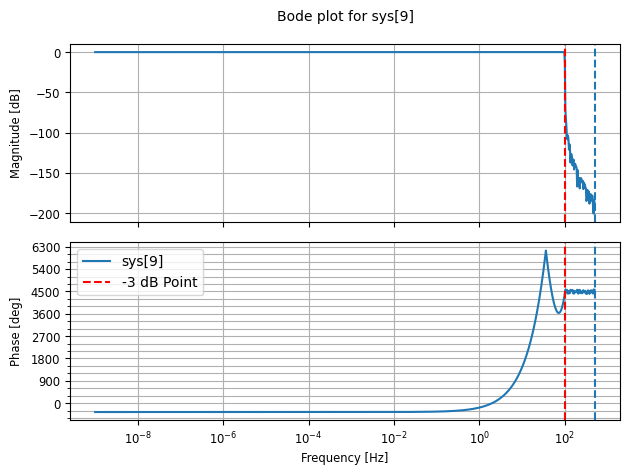

In [12]:
kernelsize = 1024
cutoff_freq = 100

# num = mylab.ideal_lowpass(kernelsize, cutoff_freq)
num = signal.firwin(window='hann', numtaps= kernelsize, cutoff= cutoff_freq, fs=kernelsize)
num = num.tolist()
den = [1]


show_info_tf(num, den, dt= 1/kernelsize, hasFind3dB=True)


* Bài tập:
    - Vẽ đặc tuyến tần số và pha cho các trường hợp sau:
        + Cửa sỗ Rectangle, Hanning, Hamming và Blackman
        + Bộ lọc sau khi áp dụng các cửa sổ trên
    - Viết đánh giá và nhận xét

## c. Xác định điểm zero và cực của hàm truyền

* Tìm điểm zero và điểm poles của hàm truyền sau:

\begin{equation}
    H(z) = \frac{1}{1 + 0.99 z^{-1} +0.99 z^{-2}+0.99 z^{-3}}
\end{equation}

* Thảo luận:
    - Tại sao chỉ có 2 điểm tăng cường ở đáp ứng tần số?
    - Các đỉnh xuất hiện ở tần số nào?
    - Hãy tính toán tần số đó?
    - Nếu hệ thống của bạn lấy mẫu ở tần số 1024Hz, hãy tính lại tần số lấy mẫu và kiểm chứng bằng thực hành.

In [4]:

def pole_zero_plot(numerator, denominator):
    plt.close('all')
    plt.figure()
    # Định nghĩa các hệ số của hàm truyền rời rạc (ví dụ)


    # Tạo hàm truyền rời rạc (với chu kỳ lấy mẫu dt)
    system = ctrl.tf(numerator, denominator, dt=1)

    # Lấy các cực và không của hệ thống
    poles, zeros = ctrl.pzmap(system, plot=False)

    # Vẽ vòng tròn đơn vị
    theta = np.linspace(0, 2 * np.pi, 100)
    plt.plot(np.cos(theta), np.sin(theta), 'b--', label='Đường tròn đơn vị')

    # Vẽ cực và không
    plt.scatter(np.real(poles), np.imag(poles), marker='x', color='red', label='Cực (Pole)')
    plt.scatter(np.real(zeros), np.imag(zeros), marker='o', color='green', label='Không (Zero)')

    # Định dạng biểu đồ
    plt.xlabel('Phần thực')
    plt.ylabel('Phần ảo')
    plt.axhline(0, color='black', lw=0.5)
    plt.axvline(0, color='black', lw=0.5)
    plt.grid(True)
    plt.legend()
    plt.title('Biểu đồ cực - không với đường tròn đơn vị trên mặt phẳng Z')
    plt.axis('equal')
    plt.show()



/opt/anaconda3/lib/python3.12/site-packages/control/pzmap.py:318: FutureWarning: pole_zero_plot() return value of poles, zeros is deprecated; use pole_zero_map()
  warnings.warn(


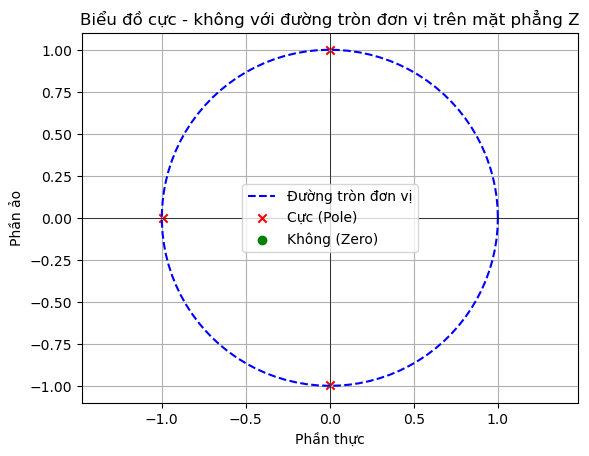

/opt/anaconda3/lib/python3.12/site-packages/control/freqplot.py:435: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


<Figure size 640x480 with 0 Axes>

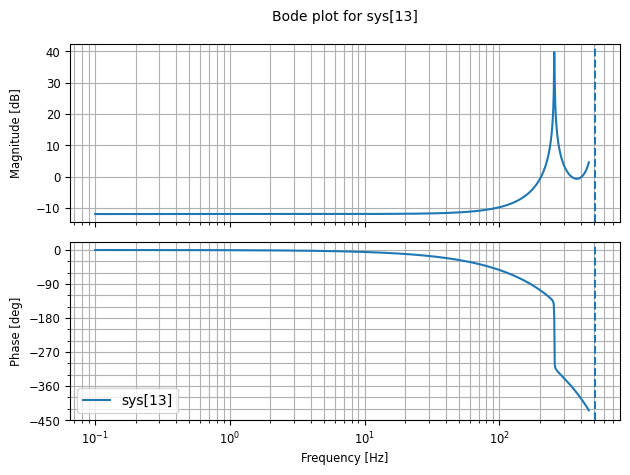

In [14]:
numerator = [1]         # Tử số
denominator = [1, 0.99,0.99,0.99] # Mẫu số
pole_zero_plot(numerator, denominator)
show_info_tf(numerator, denominator, dt=1/1024)



* Vẽ điểm zeros và cực của bộ lọc FIR đã học



/opt/anaconda3/lib/python3.12/site-packages/control/pzmap.py:318: FutureWarning: pole_zero_plot() return value of poles, zeros is deprecated; use pole_zero_map()
  warnings.warn(


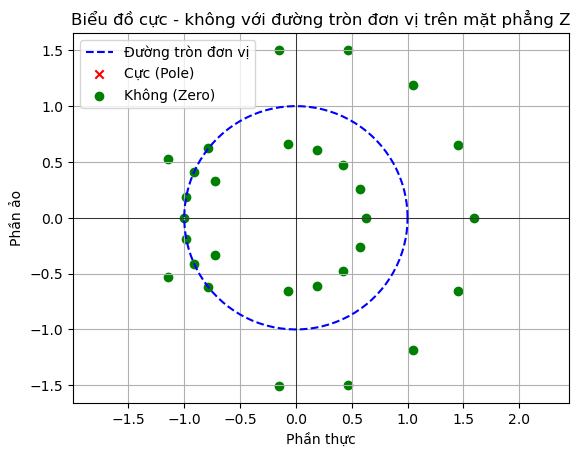

/opt/anaconda3/lib/python3.12/site-packages/control/freqplot.py:435: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

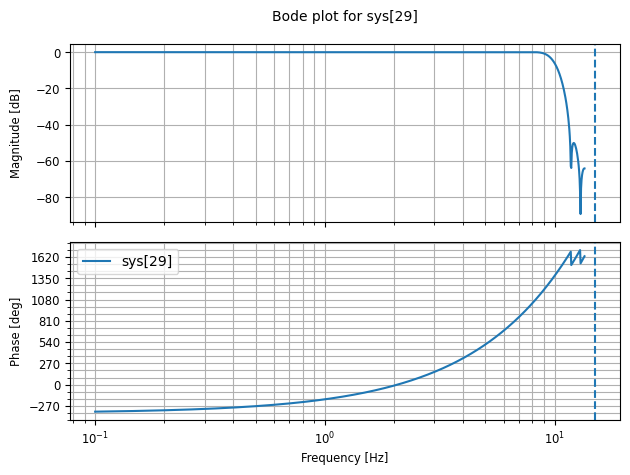

In [18]:
kernelsize = 30
cutoff_freq = 10
cutoff = 2*cutoff_freq/kernelsize  # Tần số cắt chuẩn hóa (f_c / (f_s / 2))
num1 = signal.firwin(kernelsize,cutoff, window='hamming')

plt.figure()
plt.stem(np.arange(kernelsize), num1, linefmt='blue')
# plt.stem(np.arange(kernelsize), num2, linefmt='red')
num = num1.tolist()
den = [1]
pole_zero_plot(num, den)
plt.figure()
show_info_tf(num, den, dt=1/kernelsize)





In [58]:
def show_info_tf2(num, den, dt=1, hasFind3dB=False, showpolezero=False):
    # Tạo hàm truyền
    system = ctrl.tf(num, den, dt=dt)

    plt.figure()
    # Vẽ biểu đồ Bode
    mag, phase, omega = ctrl.bode_plot(system, dB=True, Hz=True, deg=True, plot=False)

    # Chuyển đổi biên độ sang decibel
    mag_db = 20 * np.log10(mag)

    # Chuyển đổi từ tần số góc sang tần số Hz
    freq = omega/ (2 * np.pi)

    # Hiển thị biểu đồ bode và vị trí tần số cắt
    ctrl.bode_plot(system, dB=True, Hz=True, deg=True, plot=True)
    # Hiển thị biểu đồ với đường dọc tại điểm -3 dB

    if hasFind3dB:
        index_3db, freq_3db = find_3dB_freq(mag_db,freq)
        # index_3db, freq_3db = 1, 1

        slope = np.gradient(mag_db[index_3db:], np.log10(freq[index_3db:]))

        # Hiển thị kết quả
        print(f"Tần số tại điểm -3 dB: {freq_3db:.4f} Hz")
        print(f"Độ dốc ngay sau điểm -3 dB: {slope[0]:.2f} dB/decade")
        plt.subplot(211)
        plt.axvline(x=freq_3db, color='r', linestyle='--', label='-3 dB Point')
        # plt.xlim([,500])
        plt.ylim([-3, 1])
        plt.subplot(212)
        plt.axvline(x=freq_3db, color='r', linestyle='--', label='-3 dB Point')
        # plt.xlim([100,500])
    plt.subplot(211)
    plt.ylim([-3, 1])
    # Lấy các cực và không
    poles, zeros = ctrl.pzmap(system, plot=False)

    # Chuyển đổi cực và không từ tần số góc sang Hz
    poles_freq = (np.abs(poles) / (2 * np.pi)) * (0.5/dt)
    zeros_freq = np.abs(zeros) / (2 * np.pi) * (0.5/dt)



    if showpolezero:
        # Hiển thị kết quả
        print(f" Điểm poles tại các vị trí: {poles} ")
        print(f"Tần số của diểm poles     : {poles_freq}")
        print(f" Điểm zeros tại các vị trí: {zeros} ")
        print(f"Tần số của diểm poles     : {zeros_freq}")
        plt.subplot(211)

        for pf in poles_freq:
            plt.axvline(pf, color='orange', linestyle='--', label='Cực')
        for zf in zeros_freq:
            plt.axvline(zf, color='g', linestyle='--', label='Không')
        # Biểu đồ pha
        plt.subplot(212)
        for pf in poles_freq:
            plt.axvline(pf, color='orange', linestyle='--')
        for zf in zeros_freq:
            plt.axvline(zf, color='g', linestyle='--')
    # plt.legend()
    plt.show()



/home/cutebamboo/anaconda3/lib/python3.12/site-packages/control/freqplot.py:435: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(
/home/cutebamboo/anaconda3/lib/python3.12/site-packages/control/pzmap.py:318: FutureWarning: pole_zero_plot() return value of poles, zeros is deprecated; use pole_zero_map()
  warnings.warn(


 Điểm poles tại các vị trí: [-0.99499994+0.j          0.00249997+0.99748117j  0.00249997-0.99748117j] 
Tần số của diểm poles     : [0.07917958 0.07937728 0.07937728]
 Điểm zeros tại các vị trí: [] 
Tần số của diểm poles     : []


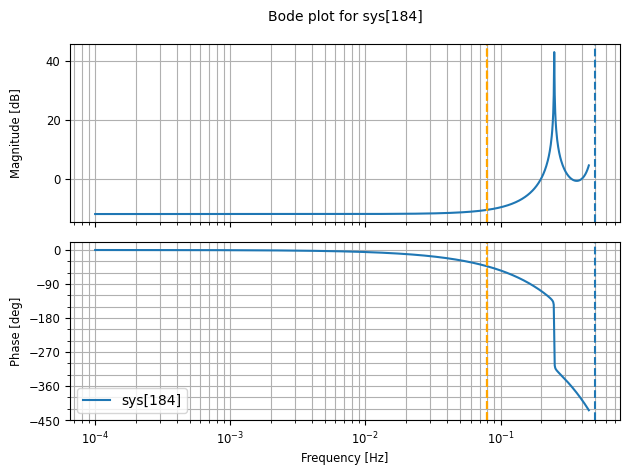

In [ ]:
numerator = [1]         # Tử số
denominator = [1, 0.99,0.99,0.99] # Mẫu số
# pole_zero_plot(numerator, denominator)
show_info_tf2(numerator, denominator, dt=1, showpolezero=True, hasFind3dB=False)

# 3. Làm sao thiết kế một bộ lọc thông thấp, thông cao, thông dải bằng bộ lọc ButterWorth


## 3.1 khởi tạo các hệ số của bộ lọc thông thấp Butterworth

* Các đặc tính cần có:
    - Bậc của bộ lọc: $n$
    - Tần số cắt mong muốn thiết kế:

Ví dụ bộ lọc butterworth ở bậc 2 và tần số 15 Hz

In [33]:

def design_butter(order, cut_freq=10, sampling_rate= 100, type = 'low'):
    # Thiết lập thông số của bộ lọc
    n = order       # Bậc của bộ lọc
    fc = cut_freq        # Tần số cắt (Hz)
    fs = sampling_rate       # Tần số lấy mẫu (Hz)
    Wn = fc / (fs / 2)  # Chuẩn hóa tần số cắt

    # Tính hệ số bộ lọc
    b, a = signal.butter(N=order, Wn=Wn, btype= type, analog=False, output='ba')
    return b, a


Hệ số b (tử số): [0.00208057 0.00416113 0.00208057]
Hệ số a (mẫu số): [ 1.         -1.86689228  0.87521455]
Tần số tại điểm -3 dB: 15.2917 Hz
Độ dốc ngay sau điểm -3 dB: -21.25 dB/decade


/opt/anaconda3/lib/python3.12/site-packages/control/freqplot.py:435: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/control/pzmap.py:318: FutureWarning: pole_zero_plot() return value of poles, zeros is deprecated; use pole_zero_map()
  warnings.warn(


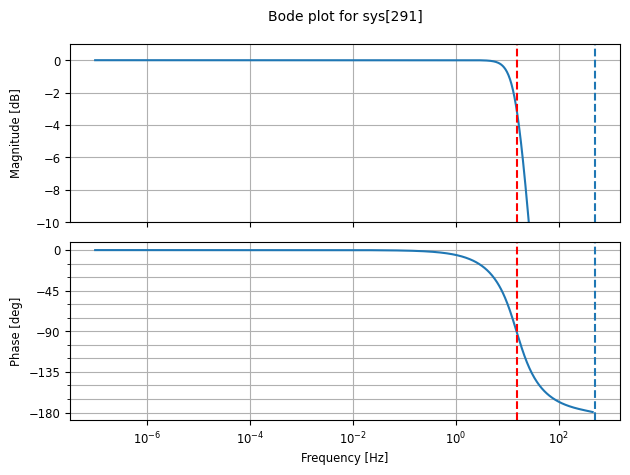

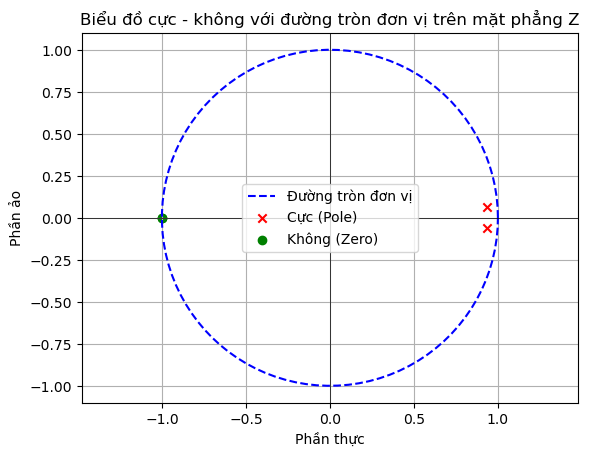

In [34]:
order = 2
cutoff_freq = 15
fs = 1000
num, den = design_butter(order, cutoff_freq, fs)
# In các hệ số
print("Hệ số b (tử số):", num)
print("Hệ số a (mẫu số):", den)

show_info_tf2(num, den, dt=1/fs, showpolezero=False, hasFind3dB=True)
plt.figure()
pole_zero_plot(num, den)

* **Các câu hỏi thảo luận:**
    - Các anh chị hãy xem bộ lọc có lọc thông thấp ở tần số 15Hz hay không
    - Các anh chị hãy lặp lại bằng cách thay đổi bậc của bộ lọc $ n = \left\{3, 4, 5 \right\}$
    - Số bậc quan hệ như thế nào đến số điểm cực?
    - Số điểm cực nằm trong hay ngoài vòng tròn đơn vị?
    - Có bao nhiêu điểm zeros trong hình vẽ?
    - Điểm zero ở vị trí nào?
    - Hãy viết chương trình bố trí các slider có thể xem sự thay đổi của đáp ứng tần số và pha, biểu đồ zero cực cho bộ lọc butterworth khi thay đổi bậc, tần số cắt, tần số lấy mẫu.

In [41]:
def showcase41(order=2, cutoff_freq=15, fs=1000):

    num, den = design_butter(order, cutoff_freq, fs)
    # In các hệ số
    print("Hệ số b (tử số):", num)
    print("Hệ số a (mẫu số):", den)

    show_info_tf2(num, den, dt=1/fs, showpolezero=False, hasFind3dB=True)
    plt.figure()
    pole_zero_plot(num, den)
    plt.subplot(211)
    plt.ylim([-10,3])
    


In [42]:
order_slider = widgets.IntSlider(value=2, min=1, max=15, step=1, layout= Layout(width='700px'))
fc_slider = widgets.FloatSlider(value= 15, min= 5, max= 100.0, step=1, layout= Layout(width='700px'))
fs_slider = widgets.FloatSlider(value= 1000, min= 100, max = 5000.0, step=1.0, layout= Layout(width='700px'))
interact(showcase41, order= order_slider, cutoff_freq= fc_slider, fs= fs_slider)

interactive(children=(IntSlider(value=2, description='order', layout=Layout(width='700px'), max=15, min=1), Fl…

<function __main__.showcase41(order=2, cutoff_freq=15, fs=1000)>

* Câu hỏi thảo luận:
    - Khi thay đổi giá trị bậc: các điểm cực có ra khỏi vòng tròn đơn vị hay không? số điểm zero có thay đổi về số điểm và vị trí hay không?
    - Khi thay đổi tần số cutoff: các điểm cực và zero thay đổi như thế nào?
    - Khi điều chỉnh giá trị fs < 2 * fc: vì sao có lỗi xảy ra. Các bạn hãy tìm hiểu và dự đoán điểm cực sẽ di chuyển như thế nào?
    

## 3.2 Bộ lọc thông cao Butterworth

![](https://kistler.cdn.celum.cloud/SAPCommerce_FullSize_1200x1200/high-pass-filter.webp)

In [59]:
def showcase42(order=2, cutoff_freq=15, fs=1000, type='low'):

    num, den = design_butter(order, cutoff_freq, fs,type=type)
    # In các hệ số
    print("Hệ số b (tử số):", num)
    print("Hệ số a (mẫu số):", den)

    show_info_tf2(num, den, dt=1/fs, showpolezero=False, hasFind3dB=False)
    # plt.subplot(211)
    # plt.ylim([-10,3])
    plt.figure()
    pole_zero_plot(num, den)

def update_showcase42a(order=2, cutoff_freq=15, fs=1000):
    showcase42(order=order, cutoff_freq=cutoff_freq, fs=fs, type='high')

In [60]:
order_slider = widgets.IntSlider(value=2, min=1, max=10, step=1, layout= Layout(width='700px'))
fc_slider = widgets.FloatSlider(value= 15, min= 5, max= 100.0, step=1, layout= Layout(width='700px'))
fs_slider = widgets.FloatSlider(value= 1000, min= 100, max = 5000.0, step=1.0, layout= Layout(width='700px'))
interact(update_showcase42a, order= order_slider, cutoff_freq= fc_slider, fs= fs_slider)

interactive(children=(IntSlider(value=2, description='order', layout=Layout(width='700px'), max=10, min=1), Fl…

<function __main__.update_showcase42a(order=2, cutoff_freq=15, fs=1000)>

* Các câu hỏi thảo luận:
    - Các anh chị hãy xem bộ lọc có lọc thông thấp ở tần số 15Hz hay không
    - Các anh chị hãy lặp lại bằng cách thay đổi bậc của bộ lọc $ n = \left\{3, 4, 5 \right\}$
    - Số bậc quan hệ như thế nào đến số điểm cực?
    - Số điểm cực nằm trong hay ngoài vòng tròn đơn vị?
    - Có bao nhiêu điểm zeros trong hình vẽ?
    - Điểm zero ở vị trí nào?
    - Hãy viết chương trình bố trí các slider có thể xem sự thay đổi của đáp ứng tần số và pha, biểu đồ zero cực cho bộ lọc butterworth khi thay đổi bậc, tần số cắt, tần số lấy mẫu.


## 3.3 Bộ lọc thông dải Butterworth

![](https://kistler.cdn.celum.cloud/SAPCommerce_FullSize_1200x1200/band-pass-filter.webp)

In [61]:
def update_showcase42b(order=2, lowcut=15,highcut=50, fs=1000):
    showcase42(order=order, cutoff_freq=np.array([lowcut, highcut]), fs=fs, type='band')

In [62]:
order_slider = widgets.IntSlider(value=2, min=1, max=10, step=1, layout= Layout(width='700px'))
flow_slider = widgets.FloatSlider(value= 15, min= 5, max= 100.0, step=1, layout= Layout(width='700px'))
fhigh_slider = widgets.FloatSlider(value= 15, min= 5, max= 100.0, step=1, layout= Layout(width='700px'))
fs_slider = widgets.FloatSlider(value= 1000, min= 100, max = 5000.0, step=1.0, layout= Layout(width='700px'))
interact(update_showcase42b, order= order_slider, lowcutoff= flow_slider, highcutoff= fhigh_slider, fs= fs_slider)

interactive(children=(IntSlider(value=2, description='order', layout=Layout(width='700px'), max=10, min=1), In…

<function __main__.update_showcase42b(order=2, lowcut=15, highcut=50, fs=1000)>

## 3.4 Thực hiện bộ lọc chặn dải

![](https://kistler.cdn.celum.cloud/SAPCommerce_FullSize_1200x1200/band-stop-filter.webp)

In [65]:
def update_showcase42c(order=2, lowcut=15,highcut=50, fs=1000):
    showcase42(order=order, cutoff_freq=np.array([lowcut, highcut]), fs=1000, type='bandstop')

In [66]:
order_slider = widgets.IntSlider(value=2, min=1, max=10, step=1, layout= Layout(width='700px'))
flow_slider = widgets.FloatSlider(value= 15, min= 5, max= 100.0, step=1, layout= Layout(width='700px'))
fhigh_slider = widgets.FloatSlider(value= 15, min= 5, max= 100.0, step=1, layout= Layout(width='700px'))
fs_slider = widgets.FloatSlider(value= 1000, min= 100, max = 5000.0, step=1.0, layout= Layout(width='700px'))
interact(update_showcase42c, order= order_slider, lowcutoff= flow_slider, highcutoff= fhigh_slider, fs= fs_slider)

interactive(children=(IntSlider(value=2, description='order', layout=Layout(width='700px'), max=10, min=1), In…

<function __main__.update_showcase42c(order=2, lowcut=15, highcut=50, fs=1000)>

# 4. Notch Filter và Peak Filter

## 4.1. Notch Filter

![](https://hardwarebee.com/wp-content/uploads/2023/02/image5-notch-filter.gif)


![](https://www.researchgate.net/publication/266618255/figure/fig8/AS:295698575708176@1447511442766/Transfer-Function-of-a-Notch-Filter.png)


![](https://images.slideplayer.com/14/4225100/slides/slide_11.jpg)

In [67]:
def showcase43(Q=2, f0=15, fs=1000, type='notch'):

    if type=='notch':
        num, den = signal.iirnotch(w0=f0 / (fs / 2), Q=Q)
    else:
        num, den = signal.iirpeak(w0=f0 / (fs / 2), Q=Q)
    # In các hệ số
    print("Hệ số b (tử số):", num)
    print("Hệ số a (mẫu số):", den)

    show_info_tf2(num, den, dt=1/fs, showpolezero=False, hasFind3dB=False)
    plt.figure()
    pole_zero_plot(num, den)

def update_showcase43a(Q=2, f0=15, fs=1000):
    showcase43(Q, f0, fs, 'notch')

In [68]:
order_slider = widgets.IntSlider(value=2, min=1, max=10, step=1, layout= Layout(width='700px'))
f_slider = widgets.FloatSlider(value= 15, min= 5, max= 100.0, step=1, layout= Layout(width='700px'))
fs_slider = widgets.FloatSlider(value= 1000, min= 100, max = 5000.0, step=1.0, layout= Layout(width='700px'))
interact(update_showcase43a, Q= order_slider, f0= flow_slider, fs= fs_slider)

interactive(children=(IntSlider(value=2, description='Q', layout=Layout(width='700px'), max=10, min=1), FloatS…

<function __main__.update_showcase43a(Q=2, f0=15, fs=1000)>

### a. Ứng dụng của bộ lọc Notch Filter

Bộ lọc Notch Filter có nhiều ứng dụng quan trọng trong các lĩnh vực khác nhau, đặc biệt là khi cần loại bỏ một tần số cụ thể hoặc một dải tần rất hẹp khỏi tín hiệu. Dưới đây là một số ứng dụng phổ biến của bộ lọc Notch:

* 1. **Loại Bỏ Nhiễu Điện Lưới**
   - Trong nhiều ứng dụng điện tử và y tế, nhiễu điện lưới từ nguồn điện (50 Hz hoặc 60 Hz tùy vào quốc gia) thường là một vấn đề lớn. Bộ lọc Notch được sử dụng để loại bỏ tần số này mà không làm ảnh hưởng đến các tín hiệu quan trọng khác.
   - Ví dụ: Trong các thiết bị y tế như máy đo điện tâm đồ (ECG), nhiễu từ lưới điện có thể ảnh hưởng đến chất lượng tín hiệu đo, do đó cần loại bỏ nó để cải thiện độ chính xác của tín hiệu.

* 2. **Ứng Dụng Trong Âm Thanh**
   - Trong các hệ thống âm thanh, bộ lọc Notch được dùng để loại bỏ các tần số cộng hưởng không mong muốn hoặc tiếng hú gây khó chịu.
   - Ví dụ: Khi có một tần số cụ thể gây ra hiện tượng cộng hưởng trong phòng, Notch Filter có thể được sử dụng để loại bỏ tần số này và cải thiện chất lượng âm thanh.

* 3. **Loại Bỏ Nhiễu trong Truyền Thông**
   - Trong truyền thông vô tuyến và xử lý tín hiệu số, bộ lọc Notch được dùng để loại bỏ các tín hiệu nhiễu hoặc tần số gây nhiễu từ các nguồn khác. Điều này giúp tăng cường độ sạch của tín hiệu truyền thông.
   - Ví dụ: Trong các hệ thống thu phát sóng vô tuyến, Notch Filter có thể loại bỏ nhiễu từ các đài phát không mong muốn hoặc từ các nguồn nhiễu khác trong dải tần.

* 4. **Ứng Dụng trong Đo Lường và Hệ Thống Điều Khiển**
   - Bộ lọc Notch được sử dụng trong các hệ thống điều khiển để loại bỏ các tần số cộng hưởng tự nhiên có thể gây dao động không mong muốn hoặc làm giảm hiệu suất của hệ thống.
   - Ví dụ: Trong hệ thống đo đạc gia tốc hoặc hệ thống điều khiển robot, bộ lọc Notch có thể loại bỏ nhiễu từ các tần số gây ra bởi dao động cơ học.

* 5. **Ứng Dụng trong Radar và Hệ Thống Xử Lý Tín Hiệu**
   - Trong radar và các hệ thống xử lý tín hiệu, bộ lọc Notch có thể loại bỏ các tần số gây nhiễu hoặc các tín hiệu không mong muốn, giúp cải thiện khả năng phát hiện và xử lý tín hiệu mục tiêu.
   - Ví dụ: Trong radar quân sự, Notch Filter được dùng để loại bỏ tín hiệu từ các nguồn gây nhiễu cố ý để bảo vệ tín hiệu radar chính.

* 6. **Ứng Dụng trong Sinh Học và Kỹ Thuật Y Sinh**
   - Bộ lọc Notch được sử dụng để loại bỏ nhiễu trong các tín hiệu sinh học như điện não đồ (EEG), điện tâm đồ (ECG) và điện cơ đồ (EMG) để tăng cường chất lượng của các phép đo sinh học.
   - Ví dụ: Trong EEG, Notch Filter có thể loại bỏ nhiễu điện lưới, giúp cho tín hiệu não rõ ràng hơn và dễ phân tích.

* 7. **Ứng Dụng trong Đo Lường Công Nghiệp**
   - Trong các thiết bị đo lường công nghiệp, Notch Filter được dùng để loại bỏ nhiễu từ các máy móc và thiết bị xung quanh, đảm bảo độ chính xác của các phép đo.

Bộ lọc Notch là một công cụ rất hữu ích khi bạn cần loại bỏ các tần số nhiễu cụ thể mà vẫn giữ nguyên các phần còn lại của tín hiệu. Điều này làm cho nó trở thành một phần quan trọng trong nhiều hệ thống kỹ thuật, từ y sinh học đến công nghiệp và truyền thông.

### b. Ứng dụng bộ lọc Notch Filter để xử lý các âm thanh trong đời sống hằng ngày

Bộ lọc Notch có thể giúp loại bỏ tiếng hú (hay còn gọi là hiện tượng *feedback*) khi để micro gần loa. Tiếng hú xảy ra khi âm thanh từ loa được micro thu lại và được khuếch đại rồi phát lại qua loa, tạo thành một vòng lặp khuếch đại liên tục ở một tần số cụ thể, dẫn đến âm thanh hú kéo dài và khó chịu.

##### Cách Sử Dụng Bộ Lọc Notch Để Loại Bỏ Tiếng Hú
Tiếng hú thường xảy ra ở một hoặc một vài tần số cụ thể, phụ thuộc vào đặc tính của phòng và hệ thống âm thanh. Bộ lọc Notch có thể được điều chỉnh để giảm hoặc loại bỏ các tần số này, ngăn ngừa vòng lặp khuếch đại âm thanh.

1. **Xác Định Tần Số Gây Hú**:
   - Bạn có thể xác định tần số gây hú bằng cách sử dụng các thiết bị đo tần số âm thanh, hoặc trong một số trường hợp, các hệ thống âm thanh hiện đại có thể tự động xác định tần số gây hú.

2. **Thiết Kế Bộ Lọc Notch**:
   - Khi tần số gây hú đã được xác định, bạn có thể thiết kế một bộ lọc Notch để loại bỏ tần số này mà không ảnh hưởng đến các tần số khác của tín hiệu âm thanh.
   - Bộ lọc Notch có hệ số chất lượng (\(Q\)) cao sẽ rất phù hợp vì nó có thể tập trung loại bỏ một tần số hẹp, giúp giảm tiếng hú mà không làm thay đổi chất lượng âm thanh tổng thể.

3. **Áp Dụng Bộ Lọc Notch**:
   - Bộ lọc Notch có thể được áp dụng trong bộ xử lý tín hiệu âm thanh (ví dụ như trong phần mềm hoặc bộ xử lý âm thanh kỹ thuật số DSP) để giảm tần số gây hú.

#### Lưu Ý
- **Sử dụng nhiều Notch Filters**: Nếu tiếng hú xảy ra ở nhiều tần số, bạn có thể cần áp dụng nhiều bộ lọc Notch cho các tần số khác nhau.
- **Điều chỉnh hệ số \(Q\)**: Hệ số \(Q\) càng cao thì dải tần loại bỏ càng hẹp. Bạn có thể thử điều chỉnh để chỉ loại bỏ tần số gây hú mà không làm mất các thành phần âm thanh khác.
- **Cách điều chỉnh micro và loa**: Đặt loa và micro sao cho tín hiệu từ loa ít có khả năng bị micro thu lại cũng là một biện pháp giảm thiểu tiếng hú.

Như vậy, bộ lọc Notch là một giải pháp hiệu quả để xử lý hiện tượng tiếng hú trong hệ thống âm thanh, giúp cải thiện trải nghiệm âm thanh tổng thể khi sử dụng micro gần loa.

## 4.2 Bộ lọc Peak

![](https://www.researchgate.net/publication/224223434/figure/fig1/AS:341668520841219@1458471531475/Peak-filter-magnitude-response.png)

![](https://i.sstatic.net/ETyxF.png)

![](https://www.electronics-tutorials.ws/wp-content/uploads/2019/05/fil166.gif?fit=403%2C225?fit=355,226)


$$
H(z) = \frac{1 + \frac{\alpha}{Q} z^{-1} + z^{-2}}{1 + \frac{\beta}{Q} z^{-1} + z^{-2}}
$$

Trong đó:
- $\omega_0$: là tần số góc chuẩn hóa (tần số trung tâm cần tăng cường hoặc suy giảm), được tính như sau:

$$
\omega_0 = \frac{2\pi f_0}{f_s}
$$

với $f_0$ là tần số trung tâm và $f_s$ là tần số lấy mẫu.

- $Q$: là hệ số chất lượng, quyết định độ rộng của dải tần được tăng cường hoặc suy giảm.

- $\alpha$ và $\beta$ phụ thuộc vào độ khuếch đại mong muốn ($G$) tại tần số $f_0$, và được xác định bởi các công thức sau:

$$
\alpha = \sin(\omega_0)
$$
$$
\beta = \alpha \cdot 10^{\frac{\text{Gain}}{40}}
$$

trong đó, $\text{Gain}$ là độ tăng cường hoặc suy giảm mong muốn tại tần số $f_0$, tính bằng dB.

Để xác định hệ số chất lượng \( Q \) từ độ rộng dải tần, bạn có thể sử dụng công thức sau:

$$
Q = \frac{f_0}{\Delta f}
$$

Trong đó:
- $ f_0 $: là tần số trung tâm của dải tần mà bạn muốn tăng cường hoặc suy giảm.
- $ \Delta f $: là độ rộng dải tần tính tại điểm -3 dB, tức là khoảng cách giữa hai tần số ở mức -3 dB so với mức đỉnh tại \( f_0 \).



In [69]:
def update_showcase43b(Q=2, f0=15, fs=1000):
    showcase43(Q, f0, fs, 'peak')

In [70]:
order_slider = widgets.IntSlider(value=2, min=1, max=10, step=1, layout= Layout(width='700px'))
f_slider = widgets.FloatSlider(value= 15, min= 5, max= 100.0, step=1, layout= Layout(width='700px'))
fs_slider = widgets.FloatSlider(value= 1000, min= 100, max = 5000.0, step=1.0, layout= Layout(width='700px'))
interact(update_showcase43b, Q= order_slider, f0= flow_slider, fs= fs_slider)

interactive(children=(IntSlider(value=2, description='Q', layout=Layout(width='700px'), max=10, min=1), FloatS…

<function __main__.update_showcase43b(Q=2, f0=15, fs=1000)>

### a. Ứng dụng của bộ lọc peak

Bộ lọc Peak, hay Peaking Filter, thường được sử dụng để tăng cường hoặc suy giảm biên độ của tín hiệu tại một dải tần số cụ thể. Đây là một công cụ linh hoạt trong việc điều chỉnh âm thanh và xử lý tín hiệu, và có nhiều ứng dụng trong các lĩnh vực khác nhau. Dưới đây là một số ứng dụng phổ biến của bộ lọc Peak:

* 1. **Ứng dụng trong xử lý âm thanh**
   - **Điều chỉnh Equalizer (EQ)**: Bộ lọc Peak được sử dụng trong các bộ chỉnh âm EQ để tăng cường hoặc giảm bớt một dải tần số cụ thể mà người dùng muốn tùy chỉnh. Ví dụ, trong một bản nhạc, bạn có thể muốn tăng cường các dải trung (midrange) để làm cho giọng hát rõ hơn, hoặc giảm bớt dải cao (treble) để giảm âm sắc chói tai.
   - **Tăng cường âm thanh trong các dải tần số cụ thể**: Trong các buổi biểu diễn trực tiếp hoặc phòng thu, bộ lọc Peak có thể tăng cường tần số của các nhạc cụ hoặc giọng hát để làm nổi bật chúng trong bản phối âm.

- 2. **Loại bỏ các tần số không mong muốn**
   - **Suy giảm tần số gây nhiễu**: Bộ lọc Peak có thể được thiết kế để suy giảm các tần số cụ thể gây ra nhiễu hoặc cộng hưởng không mong muốn. Ví dụ, nếu có một tần số cụ thể gây tiếng ồn, bộ lọc Peak có thể giảm bớt tần số đó mà không làm ảnh hưởng đến các phần khác của tín hiệu.
   - **Giảm bớt các tần số cộng hưởng trong phòng**: Trong các hệ thống âm thanh cố định như trong các buổi hòa nhạc hoặc nhà hát, bộ lọc Peak có thể được sử dụng để giảm bớt các tần số cộng hưởng không mong muốn trong phòng.

* 3. **Ứng dụng trong xử lý tín hiệu**
   - **Điều chỉnh đặc tính của tín hiệu**: Bộ lọc Peak giúp điều chỉnh đặc tính tần số của tín hiệu, cho phép các kỹ sư âm thanh tùy chỉnh tín hiệu sao cho phù hợp với môi trường phát sóng hoặc phát lại.
   - **Ứng dụng trong các hệ thống truyền thông**: Trong các hệ thống truyền thông không dây, bộ lọc Peak có thể được sử dụng để giảm bớt hoặc tăng cường các dải tần cụ thể trong tín hiệu truyền đi, nhằm đạt được hiệu suất tốt hơn.

* 4. **Ứng dụng trong y sinh và đo lường**
   - **Điều chỉnh tín hiệu sinh học**: Trong y học, bộ lọc Peak có thể được sử dụng để điều chỉnh các tín hiệu sinh học như tín hiệu điện tim (ECG) hoặc điện não (EEG), giúp loại bỏ nhiễu mà không làm mất đi các đặc điểm quan trọng của tín hiệu.
   - **Hệ thống đo lường**: Bộ lọc Peak có thể được sử dụng để tăng cường hoặc giảm bớt các dải tần số trong tín hiệu đo lường, giúp cải thiện độ chính xác của các thiết bị đo.

* 5. **Các ứng dụng khác**
   - **Điều chỉnh âm thanh trong các thiết bị điện tử cá nhân**: Nhiều thiết bị điện tử như điện thoại di động, máy tính xách tay, hoặc tai nghe sử dụng bộ lọc Peak để tối ưu hóa âm thanh cho người dùng.
   - **Ứng dụng trong các công cụ nhạc cụ điện tử**: Các bộ lọc Peak thường được tích hợp vào các nhạc cụ điện tử để điều chỉnh âm thanh theo ý muốn của nghệ sĩ.



### c. Suy giảm một dải nào đó trong bộ equalizer



/var/folders/vk/m995pdvx3919575ds09dyx540000gn/T/ipykernel_1556/1063721103.py:18: RuntimeWarning: divide by zero encountered in log10
  plt.plot(w, 20 * np.log10(abs(h)), 'b')


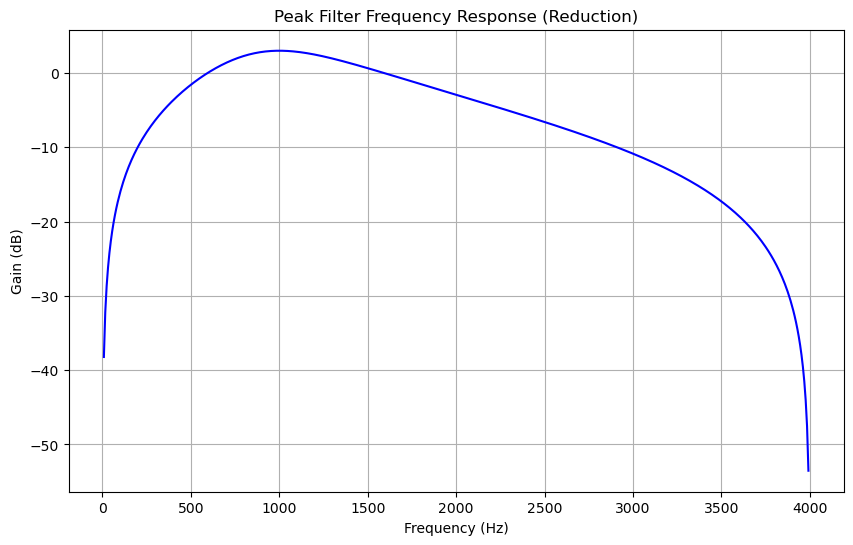

In [71]:

# Thông số của bộ lọc Peak
fs = 8000         # Tần số lấy mẫu (Hz)
f0 = 1000         # Tần số trung tâm cần giảm bớt (Hz)
Q = 1            # Hệ số chất lượng (Q)
gain_db = 3     # Mức suy giảm (dB), nếu là dB âm thì giảm bớt tần số, nếu dương thì tăng cường

# Tạo bộ lọc Peak với mức suy giảm
b, a = signal.iirpeak(w0=f0 / (fs / 2), Q=Q)

# Áp dụng mức suy giảm bằng cách điều chỉnh hệ số b
b = b * (10**(gain_db / 20))

# Tính toán đáp ứng tần số của bộ lọc
w, h = signal.freqz(b, a, fs=fs)

# Vẽ đáp ứng tần số
plt.figure(figsize=(10, 6))
plt.plot(w, 20 * np.log10(abs(h)), 'b')
plt.title('Peak Filter Frequency Response (Reduction)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Gain (dB)')
plt.grid(True)
plt.show()


# 5. Tương tự các bạn hãy phát triển các bộ loc

Bộ lọc Chebyshev loại I:
Bộ lọc Chebyshev loại II:
Bộ lọc Ellipse:
Bộ lọc Elliptic (Cauer):
Bộ lọc Bessel:

Danh sách các hàm tham khảo trong thư viện scipy.signal

b, a = cheby1(N, rp, Wn, btype='low', analog=False, output='ba')

b, a = cheby2(N, rs, Wn, btype='low', analog=False, output='ba')

b, a = ellip(N, rp, rs, Wn, btype='low', analog=False, output='ba')

b, a = bessel(N, Wn, btype='low', analog=False, output='ba', norm='phase')


Một số lưu ý về các điểm khác nhau so với bộ lọc butter

![](https://analogcircuitdesign.com/wp-content/uploads/elementor/thumbs/butterworth_vs_chebyshev-1-e1695650298890-qcxn6fb7bvct7wdwmx4w7n9141dlv7tw1scrjw4pki.png)


![](https://www.advsolned.com/wp-content/uploads/2018/08/ellip-550.png)


![](https://ecstudiosystems.com/discover/textbooks/basic-electronics/filters/images/bessel-filter.jpg)

* **Câu hỏi thảo luận:**
    - Khi nào sử dụng các loại bộ lọc khác nhau?

    - **Butterworth**: Khi cần đáp ứng tần số mượt mà, ổn định.
    - **Chebyshev I**: Khi cần độ dốc cao hơn và chấp nhận gợn sóng trong băng thông.
    - **Chebyshev II**: Khi cần băng thông mượt và chấp nhận gợn sóng trong băng dừng.
    - **Elliptic**: Khi cần độ dốc chuyển rất cao và có thể chấp nhận gợn sóng ở cả hai băng.
    - **Bessel**: Khi cần duy trì độ trung thực về pha, hạn chế méo pha.

* **Câu hỏi thảo luận, khi nào dùng FIR, IIR?**
